# Lab 5.3 Ordenado - CIFAR-10 (PyTorch)
## Comparación de optimizadores: SGD vs Adam

Este cuadernillo está reorganizado para explicar con claridad cada fase del proceso.
Se mantiene la lógica del laboratorio original, pero con estructura más didáctica.


## Estructura del notebook
1. Preparación e imports
2. Carga de CIFAR-10
3. Entender qué significan los números del dataset
4. Split Train/Validation/Test
5. Dataset y DataLoader
6. Modelo MLP reducido
7. Entrenamiento configurable por optimizador
8. Experimento comparativo: SGD vs Adam
9. Visualizaciones y conclusiones técnicas
10. Predicción manual con el mejor modelo


## 1) Preparación e imports


In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print('Device:', DEVICE)


Device: cuda


## 2) Carga de CIFAR-10


In [2]:
def unpickle(file):
    with open(file, 'rb') as fo:
        return pickle.load(fo, encoding='bytes')

ruta_cifar = '../Datasets/3_cifar-10-batches-py/'

meta = unpickle(os.path.join(ruta_cifar, 'batches.meta'))
class_names = [x.decode('utf-8') for x in meta[b'label_names']]

X_train_list, y_train_list = [], []
for i in range(1, 6):
    batch = unpickle(os.path.join(ruta_cifar, f'data_batch_{i}'))
    X_train_list.append(batch[b'data'])
    y_train_list.extend(batch[b'labels'])

X_train_full = np.vstack(X_train_list).astype(np.float32)  # (50000, 3072)
y_train_full = np.array(y_train_list, dtype=np.int64)

test_batch = unpickle(os.path.join(ruta_cifar, 'test_batch'))
X_test = test_batch[b'data'].astype(np.float32)            # (10000, 3072)
y_test = np.array(test_batch[b'labels'], dtype=np.int64)

print('Train full:', X_train_full.shape, y_train_full.shape)
print('Test      :', X_test.shape, y_test.shape)
print('Clases    :', class_names)


/tmp/ipykernel_407029/2482894145.py:3: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return pickle.load(fo, encoding='bytes')


Train full: (50000, 3072) (50000,)
Test      : (10000, 3072) (10000,)
Clases    : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 3) Qué significan los números del dataset


### Vista tabular de los valores numéricos (primeras 10 filas)

Esto permite ver los 3072 valores por imagen en formato de tabla, junto con la etiqueta.


In [4]:
import pandas as pd

# Vista tabular opcional de una muestra del dataset
# Se ejecuta solo si existen variables de entrenamiento en memoria.
if 'X_train' in globals() and 'y_train' in globals():
    df_preview = pd.DataFrame(X_train[:10])
    df_preview['label'] = y_train[:10]
    display(df_preview)
elif 'X_train_full' in globals() and 'y_train_full' in globals():
    df_preview = pd.DataFrame(X_train_full[:10])
    df_preview['label'] = y_train_full[:10]
    display(df_preview)
else:
    print('Primero ejecutá la celda de carga de CIFAR-10 para definir X_train/y_train o X_train_full/y_train_full.')


,0,1,2,3,4,5,6,7,8,9,...,3063,3064,3065,3066,3067,3068,3069,3070,3071,label
0,59.0,43.0,50.0,68.0,98.0,119.0,139.0,145.0,149.0,149.0,...,58.0,65.0,59.0,46.0,57.0,104.0,140.0,84.0,72.0,6
1,154.0,126.0,105.0,102.0,125.0,155.0,172.0,180.0,142.0,111.0,...,42.0,67.0,101.0,122.0,133.0,136.0,139.0,142.0,144.0,9
2,255.0,253.0,253.0,253.0,253.0,253.0,253.0,253.0,253.0,253.0,...,83.0,80.0,69.0,66.0,72.0,79.0,83.0,83.0,84.0,9
3,28.0,37.0,38.0,42.0,44.0,40.0,40.0,24.0,32.0,43.0,...,39.0,59.0,42.0,44.0,48.0,38.0,28.0,37.0,46.0,4
4,170.0,168.0,177.0,183.0,181.0,177.0,181.0,184.0,189.0,189.0,...,88.0,85.0,82.0,83.0,79.0,78.0,82.0,78.0,80.0,1
5,159.0,150.0,153.0,154.0,138.0,184.0,154.0,77.0,61.0,64.0,...,18.0,16.0,12.0,13.0,16.0,14.0,14.0,17.0,19.0,1
6,164.0,105.0,118.0,129.0,134.0,146.0,166.0,183.0,199.0,174.0,...,71.0,48.0,58.0,64.0,48.0,41.0,29.0,26.0,44.0,2
7,28.0,30.0,33.0,62.0,63.0,31.0,29.0,42.0,55.0,67.0,...,83.0,107.0,110.0,97.0,113.0,117.0,100.0,99.0,96.0,7
8,134.0,131.0,128.0,133.0,139.0,140.0,134.0,121.0,124.0,124.0,...,233.0,224.0,208.0,145.0,116.0,128.0,136.0,137.0,138.0,8
9,125.0,110.0,102.0,106.0,106.0,141.0,175.0,175.0,148.0,106.0,...,62.0,67.0,70.0,75.0,79.0,81.0,82.0,84.0,86.0,3


Etiqueta numérica: 6 | Clase: frog
Primeros 20 valores del vector plano:
[ 59  43  50  68  98 119 139 145 149 149 131 125 142 144 137 129 137 134
 124 139]


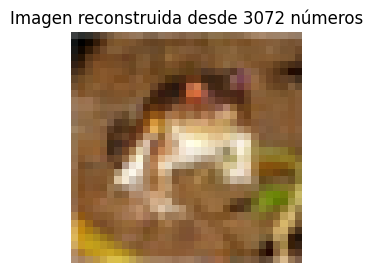

In [5]:
idx = 0
print('Etiqueta numérica:', y_train_full[idx], '| Clase:', class_names[y_train_full[idx]])
print('Primeros 20 valores del vector plano:')
print(X_train_full[idx][:20].astype(int))

# Cada imagen tiene 3072 números = 32x32x3
# 1024 para canal R, 1024 para G, 1024 para B
img = X_train_full[idx].reshape(3, 32, 32).transpose(1, 2, 0).astype(np.uint8)
plt.figure(figsize=(3,3))
plt.imshow(img)
plt.title('Imagen reconstruida desde 3072 números')
plt.axis('off')
plt.show()


## 4) Split Train / Validation / Test


In [6]:
# Escalamos a [0,1]
X_train_full = X_train_full / 255.0
X_test = X_test / 255.0

# Split estratificado simple manual
n = len(X_train_full)
indices = np.random.permutation(n)
cut = int(0.8 * n)
idx_tr, idx_val = indices[:cut], indices[cut:]

X_tr, y_tr = X_train_full[idx_tr], y_train_full[idx_tr]
X_val, y_val = X_train_full[idx_val], y_train_full[idx_val]
X_te, y_te = X_test, y_test

print('Train:', X_tr.shape, y_tr.shape)
print('Val  :', X_val.shape, y_val.shape)
print('Test :', X_te.shape, y_te.shape)


Train: (40000, 3072) (40000,)
Val  : (10000, 3072) (10000,)
Test : (10000, 3072) (10000,)


## 5) Dataset y DataLoader


In [7]:
class CIFAR10Dataset(Dataset):
    def __init__(self, X, y, mean=None, std=None):
        if mean is None:
            mean = X.mean(axis=0)
        if std is None:
            std = X.std(axis=0) + 1e-8
        Xn = (X - mean) / std
        self.X = torch.tensor(Xn, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

mean_tr = X_tr.mean(axis=0)
std_tr = X_tr.std(axis=0) + 1e-8

train_ds = CIFAR10Dataset(X_tr, y_tr, mean_tr, std_tr)
val_ds   = CIFAR10Dataset(X_val, y_val, mean_tr, std_tr)
test_ds  = CIFAR10Dataset(X_te, y_te, mean_tr, std_tr)

BATCH_SIZE = 256
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

xb, yb = next(iter(train_loader))
print('Batch X:', xb.shape, '| Batch y:', yb.shape)


Batch X: torch.Size([256, 3072]) | Batch y: torch.Size([256])


## 6) Modelo MLP reducido

In [8]:
class MLP_CIFAR10(nn.Module):
    def __init__(self, in_features=3072, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.net(x)

model_demo = MLP_CIFAR10()
params = sum(p.numel() for p in model_demo.parameters() if p.requires_grad)
print('Parámetros entrenables:', params)


Parámetros entrenables: 1740426


## 7) Función de entrenamiento configurable (SGD o Adam)


In [9]:
def make_optimizer(model, optimizer_name='adam', lr=1e-3):
    name = optimizer_name.lower()
    if name == 'adam':
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    elif name == 'sgd':
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=1e-4)
    else:
        raise ValueError('optimizer_name debe ser "adam" o "sgd"')


def fit(model, train_loader, val_loader, optimizer_name='adam', epochs=20, lr=1e-3, device='cpu', ckpt_prefix='cifar'):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = make_optimizer(model, optimizer_name=optimizer_name, lr=lr)

    best_path = f'./checkpoints/{ckpt_prefix}_{optimizer_name}_best.pth'
    os.makedirs('./checkpoints', exist_ok=True)

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [],   'val_acc': []
    }

    best_val_acc = -1.0
    print(f'Inicio entrenamiento con {optimizer_name.upper()}: {epochs} épocas')

    for epoch in range(1, epochs + 1):
        model.train()
        tr_loss, tr_ok, tr_total = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            tr_loss += loss.item() * xb.size(0)
            tr_ok += (logits.argmax(1) == yb).sum().item()
            tr_total += yb.size(0)

        model.eval()
        va_loss, va_ok, va_total = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb)
                va_loss += loss.item() * xb.size(0)
                va_ok += (logits.argmax(1) == yb).sum().item()
                va_total += yb.size(0)

        t_loss = tr_loss / tr_total
        t_acc = 100.0 * tr_ok / tr_total
        v_loss = va_loss / va_total
        v_acc = 100.0 * va_ok / va_total

        history['train_loss'].append(t_loss)
        history['train_acc'].append(t_acc)
        history['val_loss'].append(v_loss)
        history['val_acc'].append(v_acc)

        if v_acc > best_val_acc:
            best_val_acc = v_acc
            torch.save(model.state_dict(), best_path)

        if epoch % 2 == 0 or epoch == 1:
            print(f'Epoch {epoch:2d}/{epochs} | loss={t_loss:.4f} acc={t_acc:.2f}% | val_loss={v_loss:.4f} val_acc={v_acc:.2f}%')

    # cargar mejor estado
    model.load_state_dict(torch.load(best_path, map_location=device, weights_only=True))
    return model, history, best_path


## 8) Experimento comparativo: optimizador actual (SGD) vs Adam


In [14]:
EPOCHS = 50
LR = 1e-3

# Misma arquitectura, distinto optimizador
model_sgd = MLP_CIFAR10()
model_adam = MLP_CIFAR10()

best_sgd, hist_sgd, path_sgd = fit(
    model_sgd, train_loader, val_loader,
    optimizer_name='sgd', epochs=EPOCHS, lr=LR,
    device=DEVICE, ckpt_prefix='cifar10_small'
)

best_adam, hist_adam, path_adam = fit(
    model_adam, train_loader, val_loader,
    optimizer_name='adam', epochs=EPOCHS, lr=LR,
    device=DEVICE, ckpt_prefix='cifar10_small'
)


Inicio entrenamiento con SGD: 50 épocas
Epoch  1/50 | loss=2.1840 acc=22.34% | val_loss=2.0485 val_acc=30.49%
Epoch  2/50 | loss=1.9726 acc=31.89% | val_loss=1.8688 val_acc=35.54%
Epoch  4/50 | loss=1.7376 acc=39.16% | val_loss=1.6702 val_acc=41.19%
Epoch  6/50 | loss=1.6107 acc=42.80% | val_loss=1.5605 val_acc=44.18%
Epoch  8/50 | loss=1.5256 acc=45.59% | val_loss=1.4868 val_acc=47.05%
Epoch 10/50 | loss=1.4645 acc=47.91% | val_loss=1.4480 val_acc=48.01%
Epoch 12/50 | loss=1.4134 acc=49.48% | val_loss=1.4008 val_acc=49.93%
Epoch 14/50 | loss=1.3725 acc=50.99% | val_loss=1.3782 val_acc=50.83%
Epoch 16/50 | loss=1.3302 acc=52.38% | val_loss=1.3507 val_acc=52.04%
Epoch 18/50 | loss=1.2992 acc=53.29% | val_loss=1.3386 val_acc=52.23%
Epoch 20/50 | loss=1.2666 acc=54.46% | val_loss=1.3257 val_acc=52.98%
Epoch 22/50 | loss=1.2383 acc=55.40% | val_loss=1.3136 val_acc=53.12%
Epoch 24/50 | loss=1.2136 acc=56.55% | val_loss=1.2956 val_acc=53.58%
Epoch 26/50 | loss=1.1869 acc=57.49% | val_loss=1.

## 9) Visualización comparativa y puntos clave


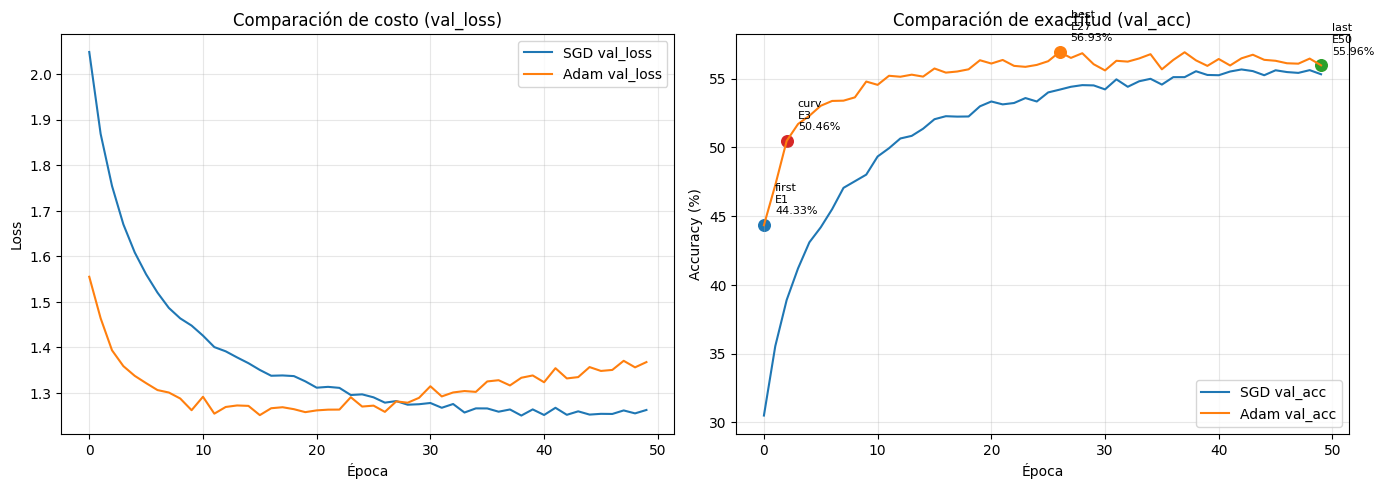

,optimizador,best_val_acc,best_epoch,last_val_acc
0,SGD,55.66,43,55.31
1,Adam,56.93,27,55.96


In [15]:
def key_points(val_acc):
    arr = np.array(val_acc, dtype=float)
    epochs = np.arange(1, len(arr)+1)

    best_idx = int(np.argmax(arr))
    best_ep, best_acc = int(epochs[best_idx]), float(arr[best_idx])

    last_idx = len(arr)-1
    last_ep, last_acc = int(epochs[last_idx]), float(arr[last_idx])

    first_ep, first_acc = int(epochs[0]), float(arr[0])

    if len(arr) >= 3:
        curv = np.abs(np.diff(arr, n=2))
        curv_idx = int(np.argmax(curv)) + 1
    else:
        curv_idx = best_idx
    curv_ep, curv_acc = int(epochs[curv_idx]), float(arr[curv_idx])

    return {
        'first': (first_ep, first_acc),
        'best': (best_ep, best_acc),
        'last': (last_ep, last_acc),
        'curv': (curv_ep, curv_acc)
    }

kp_sgd = key_points(hist_sgd['val_acc'])
kp_adam = key_points(hist_adam['val_acc'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# loss
axes[0].plot(hist_sgd['val_loss'], label='SGD val_loss')
axes[0].plot(hist_adam['val_loss'], label='Adam val_loss')
axes[0].set_title('Comparación de costo (val_loss)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.3)
axes[0].legend()

# accuracy
axes[1].plot(hist_sgd['val_acc'], label='SGD val_acc')
axes[1].plot(hist_adam['val_acc'], label='Adam val_acc')
axes[1].set_title('Comparación de exactitud (val_acc)')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy (%)')
axes[1].grid(alpha=0.3)
axes[1].legend()

# puntos clave en Adam
for name, (ep, acc) in kp_adam.items():
    x = ep - 1
    axes[1].scatter([x], [acc], s=70)
    label = f"{name}\nE{ep}\n{acc:.2f}%"
    axes[1].annotate(label, (x, acc), textcoords='offset points', xytext=(8,8), fontsize=8)

plt.tight_layout()
plt.show()

summary = pd.DataFrame([
    {
        'optimizador': 'SGD',
        'best_val_acc': max(hist_sgd['val_acc']),
        'best_epoch': int(np.argmax(hist_sgd['val_acc'])+1),
        'last_val_acc': hist_sgd['val_acc'][-1]
    },
    {
        'optimizador': 'Adam',
        'best_val_acc': max(hist_adam['val_acc']),
        'best_epoch': int(np.argmax(hist_adam['val_acc'])+1),
        'last_val_acc': hist_adam['val_acc'][-1]
    }
])

display(summary)



## 10) Evaluación en test del mejor optimizador


In [16]:
def eval_test(model, test_loader, device='cpu'):
    model.eval()
    ok, total = 0, 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            ok += (logits.argmax(1) == yb).sum().item()
            total += yb.size(0)
    return 100.0 * ok / total

acc_test_sgd = eval_test(best_sgd.to(DEVICE), test_loader, DEVICE)
acc_test_adam = eval_test(best_adam.to(DEVICE), test_loader, DEVICE)

print(f'Test accuracy SGD : {acc_test_sgd:.2f}%')
print(f'Test accuracy Adam: {acc_test_adam:.2f}%')

best_model = best_adam if acc_test_adam >= acc_test_sgd else best_sgd
best_name = 'Adam' if acc_test_adam >= acc_test_sgd else 'SGD'
print('Mejor optimizador final:', best_name)


Test accuracy SGD : 55.37%
Test accuracy Adam: 56.38%
Mejor optimizador final: Adam


## 11) Predicción manual de una imagen


In [17]:
from PIL import Image
import tkinter as tk
from tkinter import filedialog

best_model = best_model.to(DEVICE)
best_model.eval()

root = tk.Tk()
root.withdraw()
ruta = filedialog.askopenfilename(
    title='Selecciona una imagen',
    filetypes=[('Imágenes', '*.jpg *.jpeg *.png *.bmp *.webp')]
)
root.destroy()

img_pil = Image.open(ruta).convert('RGB').resize((32, 32))
img_flat = np.array(img_pil, dtype=np.float32) / 255.0
img_flat = img_flat.transpose(2, 0, 1).flatten()
img_norm = (img_flat - mean_tr) / std_tr
x_in = torch.tensor(img_norm, dtype=torch.float32).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    probs = torch.softmax(best_model(x_in), dim=1)[0]
    idx = probs.argmax().item()
    conf = probs[idx].item() * 100

print(f'Predicción: {class_names[idx].upper()} ({conf:.1f}%) con {best_name}')


Predicción: TRUCK (93.1%) con Adam
